In [2]:
import sys
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'opencv-python', 'numpy', 'Pillow'])
print("Done!")

Defaulting to user installation because normal site-packages is not writeable
Done!


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [4]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("Libraries loaded!")


Libraries loaded!


In [5]:
def encode_message(image_path, secret_message, output_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    secret_message += "$$END$$"
    binary_message = ''.join(format(ord(c), '08b') for c in secret_message)
    
    if len(binary_message) > img.size:
        print("Error: Message too long for this image!")
        return
    
    flat_img = img.flatten().astype(np.uint8)
    for i, bit in enumerate(binary_message):
        flat_img[i] = (flat_img[i] & 0xFE) | int(bit)
    
    encoded_img = flat_img.reshape(img.shape)
    Image.fromarray(encoded_img).save(output_path)
    print(f"Message hidden successfully! Saved as: {output_path}")

print("Encode function ready!")

Encode function ready!


In [6]:
def decode_message(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    flat_img = img.flatten()
    binary_message = ''.join(str(flat_img[i] & 1) for i in range(len(flat_img)))
    
    message = ''
    for i in range(0, len(binary_message), 8):
        byte = binary_message[i:i+8]
        char = chr(int(byte, 2))
        message += char
        if message.endswith("$$END$$"):
            message = message[:-7]
            break
    
    return message

print("Decode function ready!")

Decode function ready!


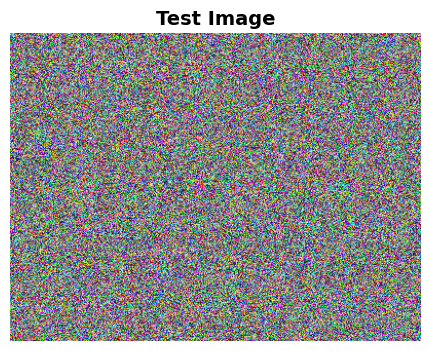

Image created and loaded!


In [8]:
# Create a simple test image instead of downloading
import numpy as np
from PIL import Image

# Create a colorful test image
img_array = np.random.randint(0, 255, (300, 400, 3), dtype=np.uint8)
Image.fromarray(img_array).save("/Users/varshinii/Downloads/test_image.png")

# Show it
img = cv2.imread("/Users/varshinii/Downloads/test_image.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.title("Test Image", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

print("Image created and loaded!")

In [9]:
secret = "Hello! This is a secret message hidden by Varshinii using Steganography!"

encode_message(
    "/Users/varshinii/Downloads/test_image.png",
    secret,
    "/Users/varshinii/Downloads/encoded_image.png"
)

Message hidden successfully! Saved as: /Users/varshinii/Downloads/encoded_image.png


In [10]:
decoded = decode_message("/Users/varshinii/Downloads/encoded_image.png")
print("=" * 55)
print("       SECRET MESSAGE EXTRACTED SUCCESSFULLY!")
print("=" * 55)
print(f"Hidden Message: {decoded}")
print("=" * 55)

       SECRET MESSAGE EXTRACTED SUCCESSFULLY!
Hidden Message: Hello! This is a secret message hidden by Varshinii using Steganography!


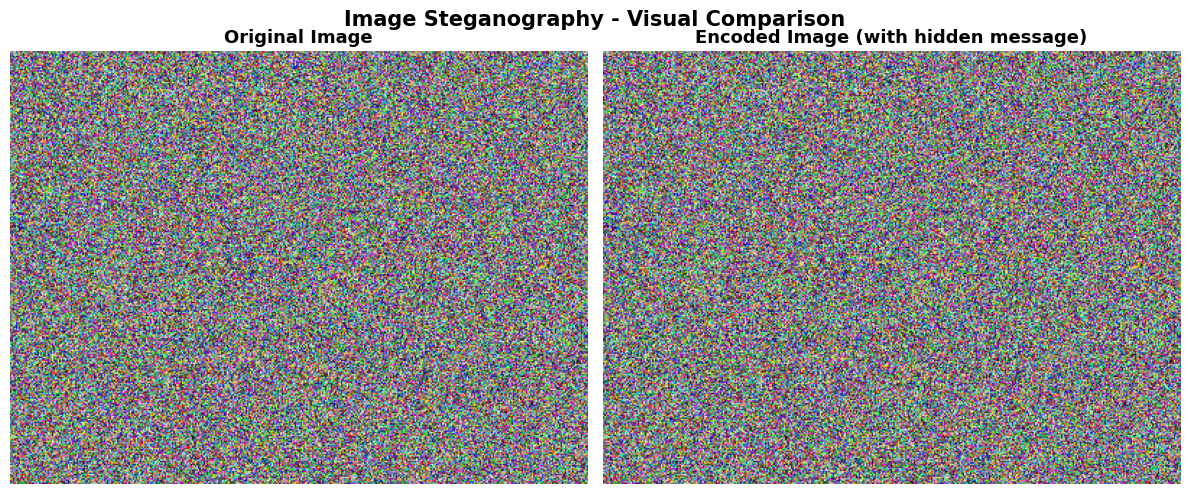

Images look identical — that's the magic of steganography!


In [11]:
original = cv2.imread("/Users/varshinii/Downloads/test_image.png")
encoded = cv2.imread("/Users/varshinii/Downloads/encoded_image.png")

original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
encoded_rgb = cv2.cvtColor(encoded, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original_rgb)
axes[0].set_title("Original Image", fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(encoded_rgb)
axes[1].set_title("Encoded Image (with hidden message)", fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Image Steganography - Visual Comparison", 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/varshinii/steganography_comparison.png', dpi=150)
plt.show()

print("Images look identical — that's the magic of steganography!")